# Crop type classification with multi-temporal Sentinel-2 (PASTIS subset)

This notebook walks through the full workflow: data inspection, exploratory analysis, splitting, preprocessing, training, evaluation and visualisation of outputs. The logic lives in `src/`; each step here either calls those functions or runs the same command-line scripts listed in the README, so every result can be reproduced outside the notebook.

| Step | Script |
|---|---|
| Data loading and inspection | `src/data_loading.py` |
| Exploratory analysis | `src/eda.py` |
| Train / validation / test split | `src/train_test_split.py` |
| Preprocessing and features | `src/preprocessing.py` |
| Training | `src/train.py` |
| Evaluation | `src/evaluate.py` |
| Output figures | `src/visualization.py` |

Key decisions and their reasons are recorded in `DECISIONS.md`; the full discussion is in `report.md`.

In [1]:
# Run from the project root so relative paths in the config resolve
import os, sys, json
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir("..")
print("Working directory:", Path.cwd())

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from src.data_loading import load_config, load_metadata, inspect_dataset
from src import eda

cfg = load_config("configs/config.yaml")
classes = {int(k): v for k, v in cfg["classes"].items()}
MET = Path(cfg["paths"]["metrics_dir"])
FIG = Path(cfg["paths"]["figures_dir"])
PY = sys.executable  # run scripts with the same Python as this kernel

Working directory: /Users/nitinsharma/Desktop/Folders/SolaFune_Assignment/Repository/solafune-cropclassification-nitinSharma


# Part 1: Data and exploratory analysis

## 1. Data loading and inspection

Each patch has a Sentinel-2 array of shape `(T, 10, H, W)` and a label array of shape `(1, H, W)`. The inspection checks that every image has a matching label and reports shapes, data types, number of observations and value ranges.

In [2]:
summary = inspect_dataset(cfg)
summary.head()

Patches with imagery and labels: 102

Shapes and dtypes
  bands per obs      : [10]
  patch size (HxW)   : [(128, 128)]
  S2 dtype(s)        : ['int16']
  label dtype(s)     : ['uint8']

Observations per patch (T)
count    102.0
mean      46.0
std        0.0
min       46.0
25%       46.0
50%       46.0
75%       46.0
max       46.0

Reflectance value range
  min -601.0 | max 20716.0
  max NaN fraction in any patch: 0.0000


,n_obs,n_bands,height,width,s2_dtype,s2_min,s2_max,s2_nan_frac,label_dtype,n_classes_in_patch
patch_id,,,,,,,,,,
30003,46,10,128,128,int16,-105.0,14924.0,0.0,uint8,8
30013,46,10,128,128,int16,0.0,12586.0,0.0,uint8,10
30014,46,10,128,128,int16,-363.0,12574.0,0.0,uint8,5
30023,46,10,128,128,int16,-175.0,11742.0,0.0,uint8,8
30026,46,10,128,128,int16,-320.0,12264.0,0.0,uint8,9


**Observations**

- 102 patches, each with imagery and labels; every patch is 128 × 128 pixels at 10 m (about 1.28 × 1.28 km).
- Every patch has exactly 46 observations with 10 bands, so all pixels share one time axis.
- Imagery is `int16` surface reflectance scaled by 10,000. Values range from −601 to 20,716: values above 10,000 are likely clouds, snow or saturation, and negatives are atmospheric-correction artefacts. Preprocessing clips to [0, 10,000] and rescales to [0, 1].
- No NaNs, but PASTIS does not mask clouds, so cloudy observations remain in the data.

## 2. Metadata: tile, dates and folds

In [3]:
meta = load_metadata(cfg["paths"]["metadata"])
print("CRS:", meta.crs)
print("Tiles:", meta["TILE"].value_counts().to_dict())
print("Patches per fold:", meta["Fold"].value_counts().sort_index().to_dict())
dates = meta.iloc[0]["dates"]
print(f"Dates: {len(dates)} from {dates[0].date()} to {dates[-1].date()}")
meta[["N_Parcel", "Parcel_Cover"]].describe().round(2)

CRS: EPSG:2154
Tiles: {'t31tfm': 102}
Patches per fold: {1: 20, 2: 23, 3: 23, 4: 18, 5: 18}
Dates: 46 from 2018-09-20 to 2019-10-25


,N_Parcel,Parcel_Cover
count,102.00,102.00
mean,49.33,0.70
std,12.69,0.14
min,21.00,0.33
25%,41.00,0.63
50%,48.00,0.71
75%,57.00,0.80
max,82.00,0.94


**Observations**

- All patches come from one Sentinel-2 tile, **T31TFM**, stored in the French Lambert-93 projection (EPSG:2154). That is why they share identical acquisition dates.
- The series runs from **20 September 2018 to 25 October 2019**: one full agricultural year, from autumn sowing of winter crops to the harvest of summer crops.
- PASTIS assigns patches to **5 spatially separated folds** (18–23 patches each), used for the split.
- Patches contain 21–82 parcels (mean about 49); on average 70% of a patch is labelled cropland.

## 3. Exploratory analysis

One pass over all patches computes the statistics below and saves tables to `outputs/metrics/` and figures to `outputs/figures/`.

In [4]:
res = eda.run_eda(cfg, show=True)
plt.close("all")  # figures are re-displayed individually below

Scanning patches: 100%|██████████| 102/102 [00:00<00:00, 269.83it/s]
/Users/nitinsharma/Desktop/Folders/SolaFune_Assignment/Repository/solafune-cropclassification-nitinSharma/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(



Patches: 102 | dates: 46 (2018-09-20 to 2019-10-25)
Clearest date: 15 Oct 2018 | dates with >50% bright pixels: 5

Class distribution:
                           class_name  pixels  pixel_share_pct  n_patches
class_id                                                                 
0                          Background  506141           30.287        102
1                              Meadow  296576           17.747        101
2                   Soft winter wheat  199108           11.914         95
3                                Corn  196704           11.770         98
4                       Winter barley   57381            3.434         64
5                     Winter rapeseed   92912            5.560         65
6                       Spring barley    3472            0.208          9
7                           Sunflower    9579            0.573         18
8                           Grapevine    1345            0.080          1
9                                Beet       0     

### 3.1 Area of interest

The patches cover roughly **4.94–5.38°E, 46.60–46.93°N**, in eastern France around the Bresse plain, east of Chalon-sur-Saône (Burgundy). The five folds are interleaved across the whole area rather than forming separate blocks, so every split samples the same landscape. That makes evaluation fair within this region, but says nothing about how the model would transfer to other regions.

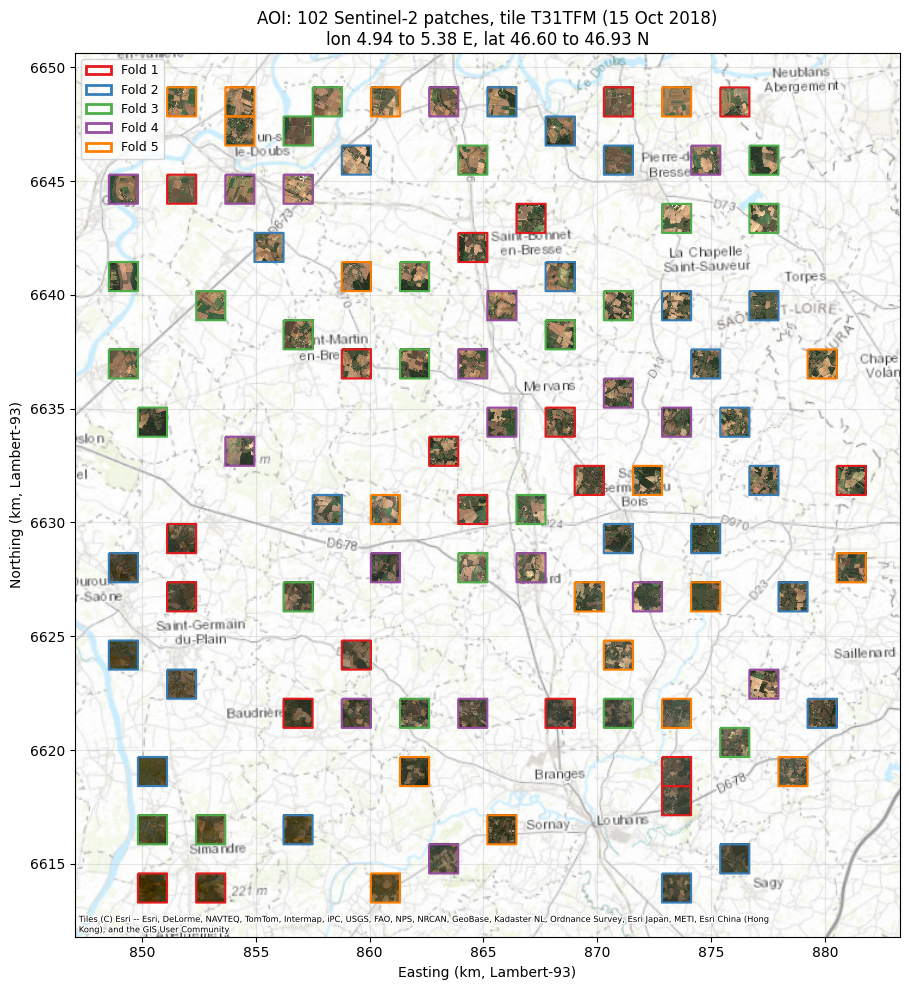

In [5]:
res["figs"]["aoi"]

### 3.2 Class distribution

The data is **heavily imbalanced** (note the log scale). Background (30.3% of pixels), meadow (17.7%), soft winter wheat (11.9%), corn (11.8%) and soybeans (7.3%) dominate. At the other end, orchard has 75 pixels, potatoes 158, durum wheat 725 and grapevine 1,345. **Beet does not occur at all.** Void labels (parcel borders and uncertain parcels) make up 8.6%.

The landscape is typical of the Bresse: permanent grassland mixed with a winter-cereal and summer-crop rotation (wheat, barley, rapeseed, then corn and soybeans). The high soybean share fits eastern France, one of the country's main soybean regions.

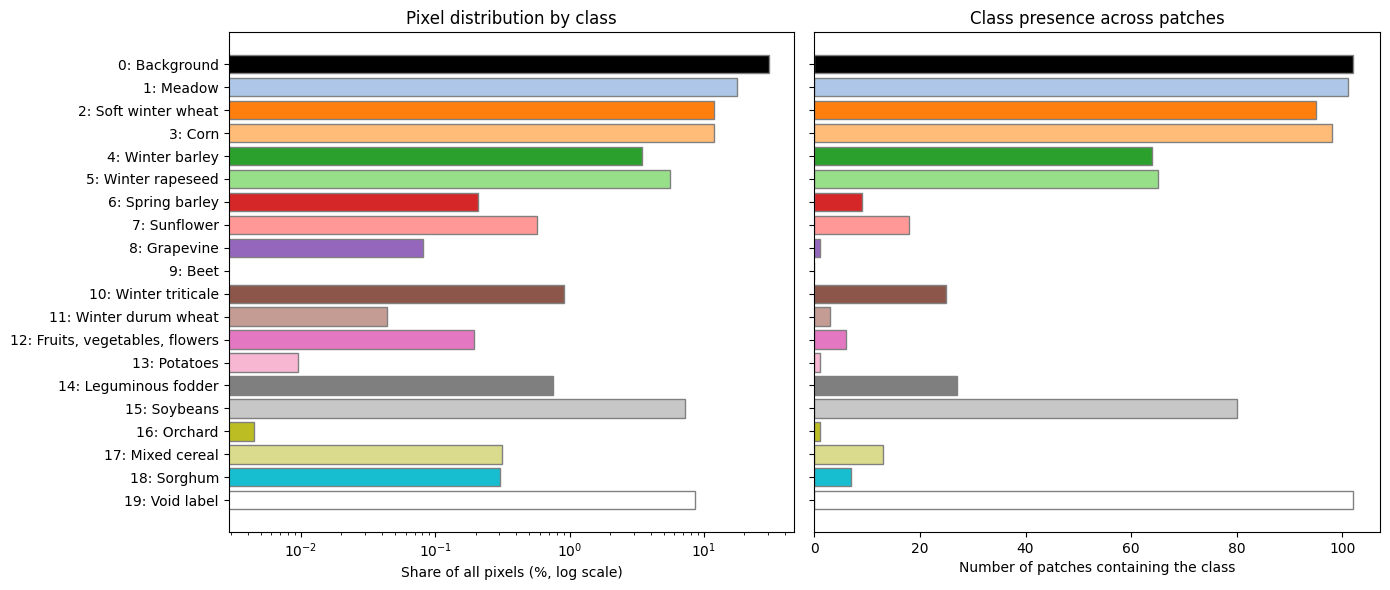

In [6]:
res["figs"]["class_distribution"]

### 3.3 Class distribution by fold

Grapevine, potatoes and orchard each occur in only one patch, so they can never appear in both training and test data. Sorghum is absent from fold 4. This informs the split and class-exclusion decisions in Part 2.

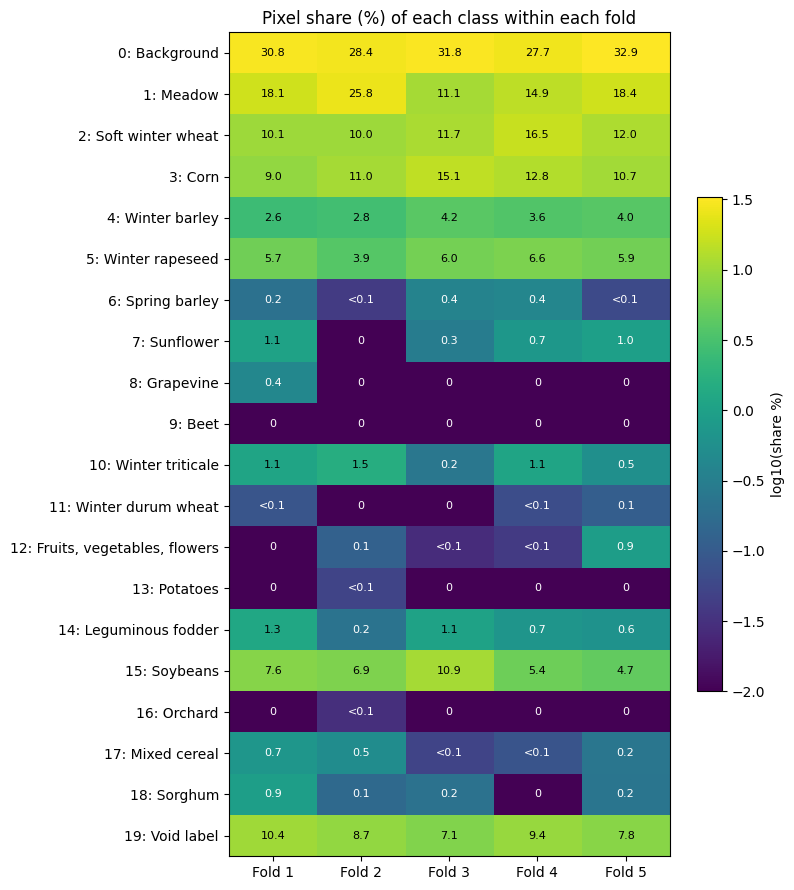

In [7]:
res["figs"]["class_by_fold"]

### 3.4 Example label maps

Labels follow whole parcels. Background (black) covers roads, buildings, forest, water, hedgerows and any land not declared as an agricultural parcel, including unregistered grassland.

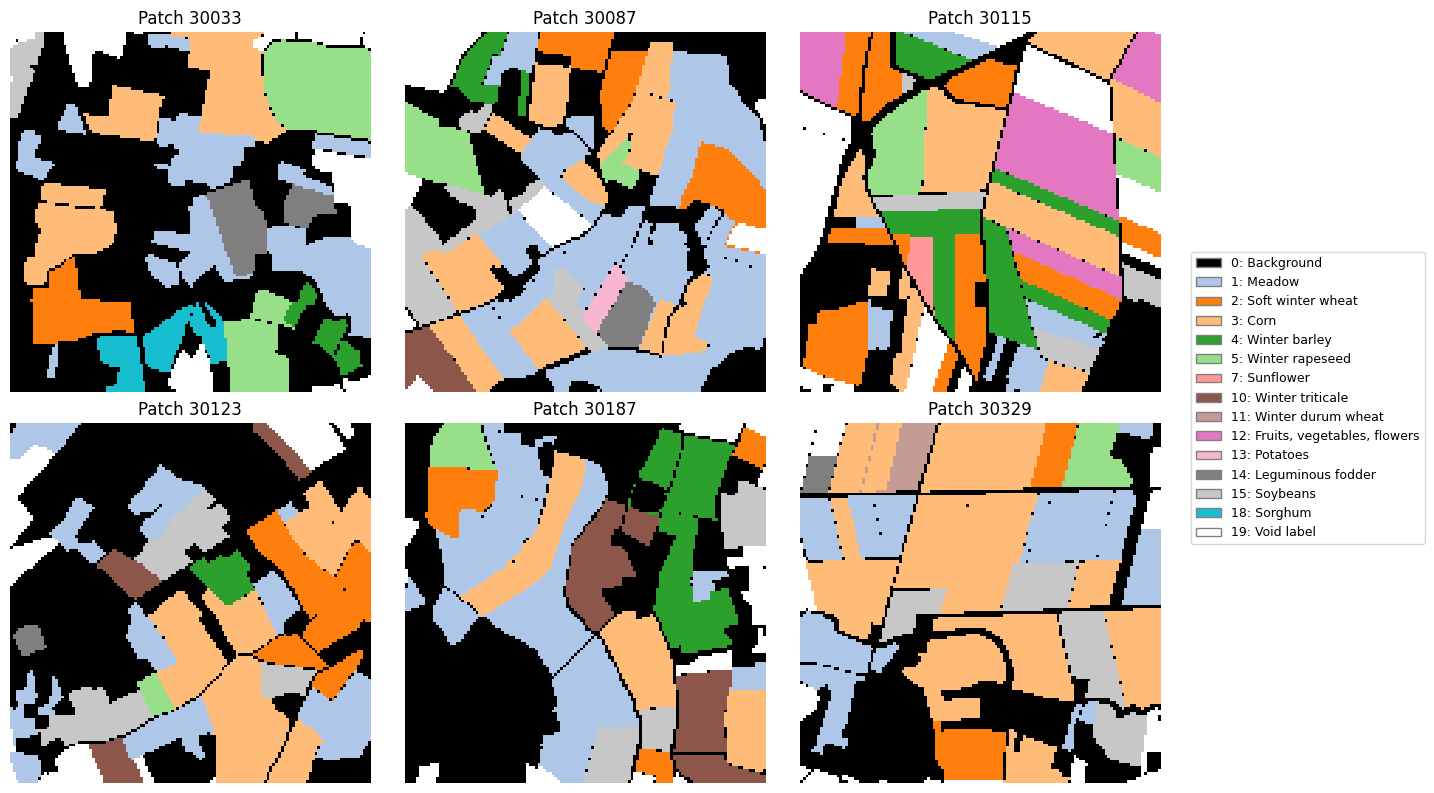

In [8]:
res["figs"]["labels"]

### 3.5 RGB composites next to labels

True colour (B4, B3, B2) on the clearest date overall, 15 October 2018, with a 2–98 percentile stretch. Most fields are harvested or freshly sown at this time, so crops are hard to tell apart from a single image; this is why the multi-temporal series is needed.

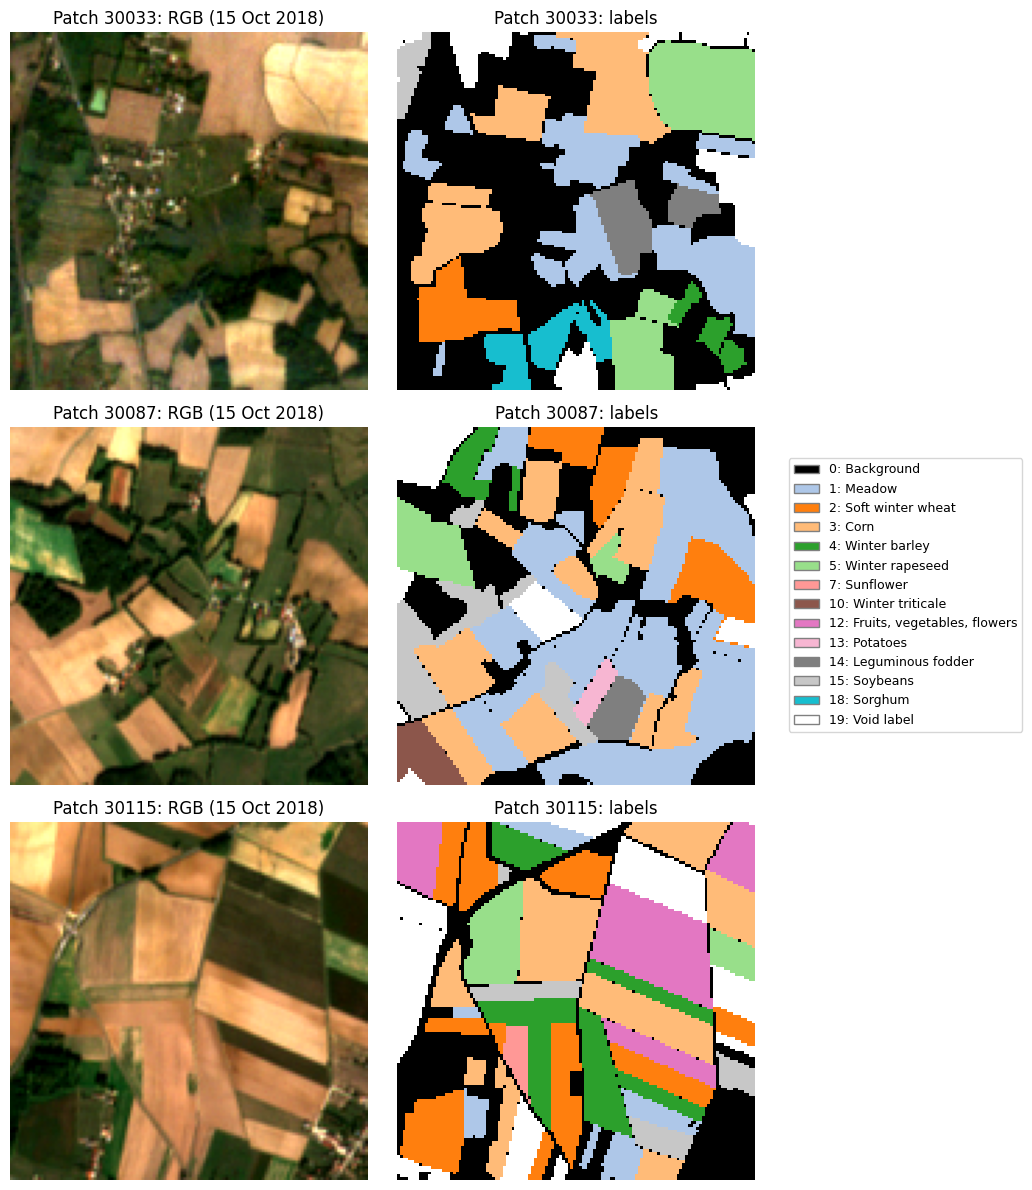

In [9]:
res["figs"]["rgb_labels"]

### 3.6 Seasonal change

The same patch at the clearest date in autumn, spring and summer: field colours change strongly through the season as crops emerge, grow and are harvested.

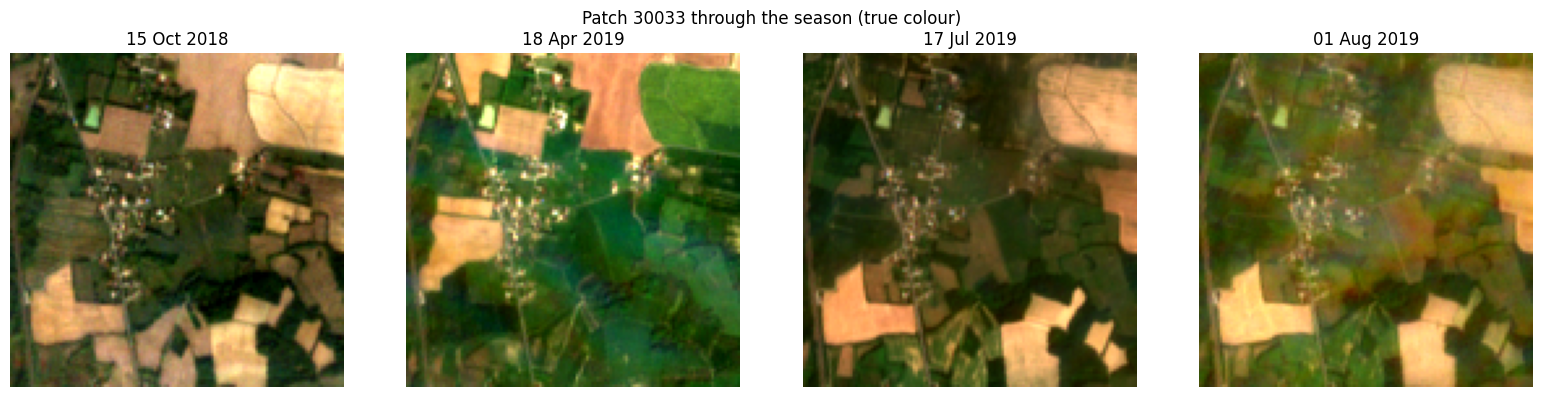

In [10]:
res["figs"]["seasonal"]

### 3.7 Cloud contamination by date

A simple proxy: the share of pixels with blue reflectance above 0.2. **Five of the 46 dates** have more than half their pixels flagged. These are removed in preprocessing (decided on training patches only).

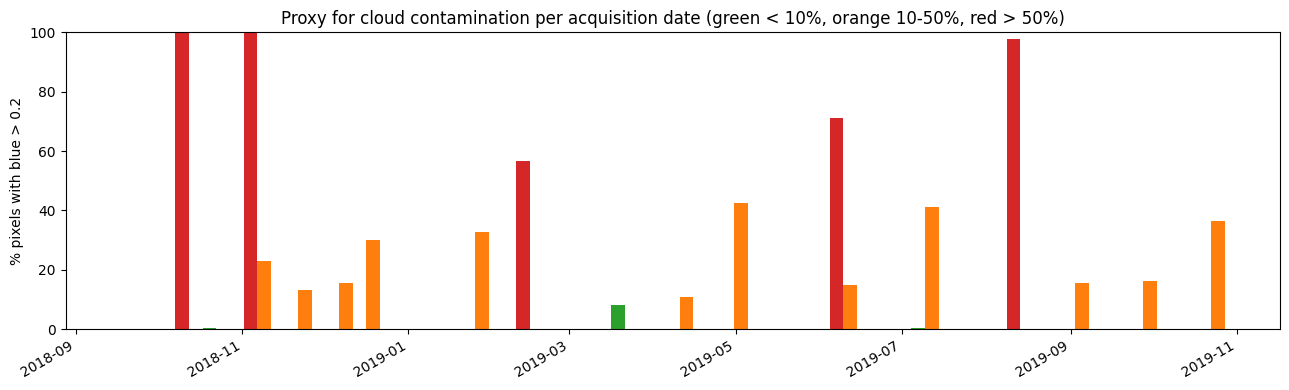

In [11]:
res["figs"]["cloud"]

### 3.8 Temporal NDVI profiles by class

Winter crops (wheat, barley, rapeseed, triticale) green up in spring and senesce by early summer; summer crops (corn, soybeans, sunflower) peak in July–August; meadow stays green most of the year. Classes with near-identical curves, such as the winter cereals (soft wheat, durum wheat, triticale, winter barley), are likely to be confused.

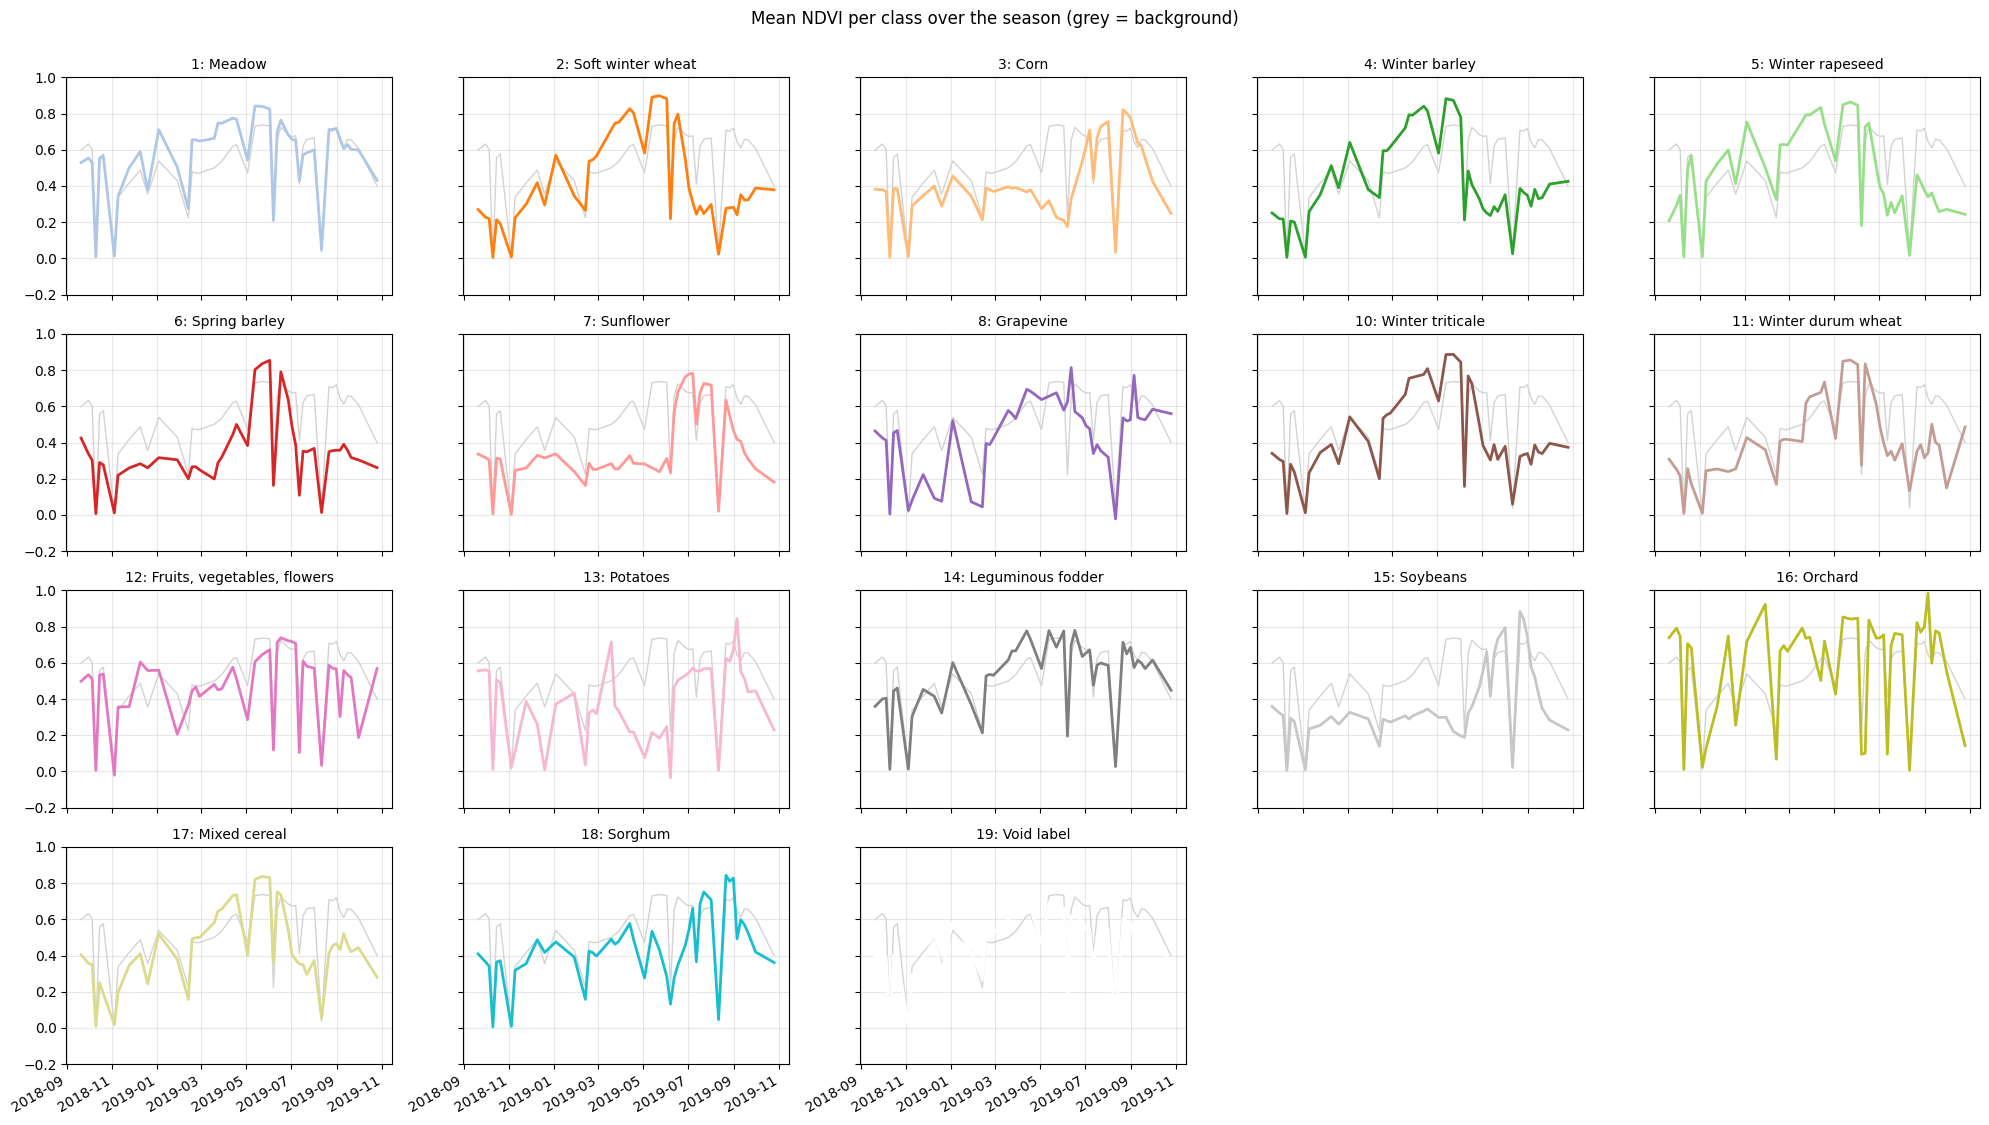

In [12]:
res["figs"]["ndvi"]

### EDA takeaways

1. **Strong class imbalance**, with several classes too rare to learn or evaluate reliably. Handled by per-class pixel sampling, class weights and excluding classes present in fewer than 3 patches.
2. **One tile, one crop calendar, one region.** No date alignment is needed, but results only describe this region.
3. **Cloudy dates** exist and are removed; remaining partial clouds are left in as noise.
4. **Similar crop calendars** among the winter cereals, and between background and meadow, suggest where confusion will occur.

# Part 2: Modelling

## 4. Train / validation / test split

The split is by **whole patch and by PASTIS fold**, never by pixel. Neighbouring pixels of the same field are near-duplicates, so a pixel-level split would leak information and inflate scores. Folds are spatially separated. The script compares all 20 possible choices of validation and test fold, then applies the one set in the config: **folds 1–3 train (66 patches), fold 4 validation (18), fold 5 test (18)**.

In [13]:
!{PY} -m src.train_test_split --config configs/config.yaml --compare

Crop classes missing from each split, for every val/test fold choice
(best first; training should never miss a class):

train_folds  val_fold  test_fold  n_train  n_val  n_test  missing_train  missing_val  missing_test
      1,2,4         3          5       61     23      18              1            5             4
      1,2,3         4          5       66     18      18              1            5             4
      1,2,4         5          3       61     18      23              1            4             5
      1,2,3         5          4       66     18      18              1            4             5
      1,2,5         3          4       61     23      18              1            5             5
      1,2,5         4          3       61     18      23              1            5             5
      2,3,4         1          5       64     20      18              2            4             4
      2,3,4         5          1       64     18      20              2            4    

**Why this split:** Beet is absent from the whole subset, so every option misses one class in training. Among the options that miss nothing else, folds 1–3 give the most training patches. The classes missing from validation or test (grapevine, potatoes, orchard) each occur in only one patch, which cannot be split without spatial leakage. These classes, and beet, are therefore **excluded from training and evaluation**, like the void label (`excluded_classes` in the config). The patch IDs of each split are saved to `outputs/splits/`.

In [14]:
pd.read_csv(MET / "split_class_coverage.csv", index_col=0)

,class_name,train_pixels,train_patches,val_pixels,val_patches,test_pixels,test_patches
class_id,,,,,,,
0,Background,327573,66,81644,18,96924,18
1,Meadow,198324,65,43893,18,54359,18
2,Soft winter wheat,114971,60,48749,18,35388,17
3,Corn,127407,64,37772,18,31525,16
4,Winter barley,34871,42,10730,11,11780,11
5,Winter rapeseed,56030,38,19554,14,17328,13
6,Spring barley,2131,5,1188,3,153,1
7,Sunflower,4607,8,2121,4,2851,6
8,Grapevine,1345,1,0,0,0,0


## 5. Preprocessing and features

1. Reflectance clipped to [0, 10,000] and scaled to [0, 1].
2. Dates where more than 50% of pixels have blue reflectance above 0.2 are dropped for all patches, decided on training patches only.
3. Four spectral indices per date: NDVI (greenness), NDWI (water), NDMI (moisture) and NDRE (red edge, chlorophyll).
4. Each pixel becomes one row: 10 bands + 4 indices at every kept date.
5. Up to 150 pixels per class per patch are sampled for the training and validation tables, which limits the dominance of large classes and spreads samples across many fields.

No standardisation is needed for tree-based models, so no statistics are learned from the data at this stage.

In [15]:
!{PY} -m src.preprocessing --config configs/config.yaml

Dates kept: 41 of 46 | dropped as cloudy: ['2018-10-10', '2018-11-04', '2019-02-12', '2019-06-07', '2019-08-11']
Features per pixel: 574 (41 dates x 14 channels)
Model classes (15): {0: 'Background', 1: 'Meadow', 2: 'Soft winter wheat', 3: 'Corn', 4: 'Winter barley', 5: 'Winter rapeseed', 6: 'Spring barley', 7: 'Sunflower', 8: 'Winter triticale', 9: 'Winter durum wheat', 10: 'Fruits, vegetables, flowers', 11: 'Leguminous fodder', 12: 'Soybeans', 13: 'Mixed cereal', 14: 'Sorghum'}
Building train: 100%|██████████████████████████| 66/66 [00:00<00:00, 88.23it/s]
train: X (66435, 574), 153 MB in memory
Building val: 100%|████████████████████████████| 18/18 [00:00<00:00, 78.89it/s]
val: X (19171, 574), 44 MB in memory

Sampled pixels per class:
                           class_name  train_samples  val_samples
model_id                                                         
0                          Background           9900         2700
1                              Meadow           9750 

In [16]:
info = json.loads((MET / "preprocessing_info.json").read_text())
print("Dropped dates:", info["dropped_dates"])
print("Features per pixel:", len(info["feature_names"]))
pd.read_csv(MET / "sampled_class_counts.csv", index_col=0)

Dropped dates: ['2018-10-10', '2018-11-04', '2019-02-12', '2019-06-07', '2019-08-11']
Features per pixel: 574


,class_name,train_samples,val_samples
model_id,,,
0,Background,9900,2700
1,Meadow,9750,2700
2,Soft winter wheat,8956,2700
3,Corn,9524,2700
4,Winter barley,6086,1579
5,Winter rapeseed,5700,2064
6,Spring barley,638,352
7,Sunflower,1200,600
8,Winter triticale,2450,450


Five dates were dropped, spread across the season, leaving **41 dates and 574 features**. Sampling reduces the imbalance from about 400:1 to about 66:1. The weakest classes remain durum wheat (150 training pixels), fruits/vegetables/flowers (307) and spring barley (638); sorghum has no validation pixels.

## 6. Training

Two models are trained on the same features:

- **Random Forest** (200 trees): a robust, low-tuning baseline and a standard choice for pixel-based crop mapping.
- **LightGBM**: gradient-boosted trees, often strongest on tabular data, with early stopping on validation macro F1.

Class imbalance is handled with sample weights proportional to **1/√(class frequency)**, a compromise between no weighting and fully balanced weights (which would up-weight durum wheat about 66× on only 150 pixels). Training runs on CPU in well under a minute per model.

In [17]:
!{PY} -m src.train --config configs/config.yaml

Train (66435, 574), validation (19171, 574), 15 classes
Class weights (sqrt_inverse): 0:0.76, 1:0.76, 2:0.80, 3:0.77, 4:0.97, 5:1.00, 6:2.98, 7:2.17, 8:1.52, 9:6.15, 10:4.30, 11:1.61, 12:0.88, 13:2.07, 14:2.51

=== Training random_forest ===
Trained in 30s | saved models/random_forest.joblib (48 MB)
Validation accuracy 0.850 | macro F1 0.660 over 14 classes
Top channels by importance: B6 0.10, NDRE 0.09, B5 0.09, NDVI 0.09, NDWI 0.08

=== Training lightgbm ===
[50]	valid_0's macro_f1: 0.614795
[100]	valid_0's macro_f1: 0.607609
Trained in 26s | saved models/lightgbm.joblib (1 MB)
Validation accuracy 0.838 | macro F1 0.625 over 14 classes
Top channels by importance: B11 0.10, B6 0.10, B5 0.08, NDWI 0.07, NDMI 0.07

Training summary saved to outputs/metrics/training_summary.json


In [18]:
ts = json.loads((MET / "training_summary.json").read_text())
pd.DataFrame({m: {"train_seconds": v["train_seconds"], "model_size_mb": v["model_size_mb"],
                  "val_accuracy": round(v["validation"]["accuracy"], 3),
                  "val_macro_f1": round(v["validation"]["macro_f1"], 3),
                  "best_iteration": v.get("best_iteration", "-")}
              for m, v in ts["models"].items()}).T

,train_seconds,model_size_mb,val_accuracy,val_macro_f1,best_iteration
lightgbm,25.5,0.7,0.838,0.625,30.0
random_forest,29.7,47.5,0.85,0.66,-


**Model selection.** LightGBM first used early stopping on validation log-loss and stopped after very few rounds: training is class-weighted but validation is not, so log-loss worsened while F1 was still improving. Switching to macro-F1 early stopping and slower boosting helped (macro F1 0.607 → 0.625), but boosting still overfits the few fields of rare classes quickly, and fold 4 is spatially separate. The **Random Forest scored higher on validation** (accuracy 0.850 vs 0.838, macro F1 0.660 vs 0.625) and was selected as the final model **before looking at test results**. No tuning was done after that point.

## 7. Evaluation on full patches

Evaluation predicts **every pixel** of each validation and test patch, not just the sampled pixels, so the scores reflect real class frequencies. Void and excluded classes are ignored when scoring. Macro F1 and mIoU average over the classes present in each split.

In [19]:
!{PY} -m src.evaluate --config configs/config.yaml

random_forest / val: 100%|█████████████████████| 18/18 [00:01<00:00, 14.94it/s]

random_forest on val (18 patches, 267,316 pixels, 1s)
  OA 0.863 | macro F1 0.670 | weighted F1 0.861 | mIoU 0.591 | mIoU crops 0.583
  not in val: Sorghum
random_forest / test: 100%|████████████████████| 18/18 [00:01<00:00, 14.07it/s]

random_forest on test (18 patches, 271,814 pixels, 1s)
  OA 0.843 | macro F1 0.501 | weighted F1 0.834 | mIoU 0.441 | mIoU crops 0.423
                           class_name  precision  recall     f1    iou  support_pixels
model_id                                                                              
0                          Background      0.874   0.769  0.818  0.692           96924
1                              Meadow      0.697   0.869  0.773  0.631           54359
2                   Soft winter wheat      0.910   0.960  0.935  0.877           35388
3                                Corn      0.924   0.930  0.927  0.864           31525
4                       W

In [20]:
pd.read_csv(MET / "model_comparison.csv")

,model,split,overall_accuracy,macro_f1,weighted_f1,miou,miou_crops_only
0,random_forest,val,0.863,0.670,0.861,0.591,0.583
1,random_forest,test,0.843,0.501,0.834,0.441,0.423
2,lightgbm,val,0.854,0.630,0.852,0.547,0.536
3,lightgbm,test,0.835,0.496,0.827,0.435,0.417


In [21]:
pc = pd.read_csv(MET / "per_class_random_forest_test.csv", index_col=0)
pc[pc.support_pixels > 0][["class_name", "precision", "recall", "f1", "iou", "support_pixels"]].round(3)

,class_name,precision,recall,f1,iou,support_pixels
model_id,,,,,,
0,Background,0.874,0.769,0.818,0.692,96924
1,Meadow,0.697,0.869,0.773,0.630,54359
2,Soft winter wheat,0.910,0.960,0.934,0.877,35388
3,Corn,0.924,0.930,0.927,0.864,31525
4,Winter barley,0.876,0.953,0.913,0.839,11780
5,Winter rapeseed,0.943,0.966,0.955,0.913,17328
6,Spring barley,0.000,0.000,0.000,0.000,153
7,Sunflower,0.734,0.853,0.789,0.651,2851
8,Winter triticale,0.305,0.054,0.092,0.048,1612


In [22]:
pd.read_csv(MET / "top_confusions_random_forest_test.csv").head(10)

,true_class,predicted_as,pixels,share_of_true_class_pct
0,Background,Meadow,17372,17.9
1,Meadow,Background,6380,11.7
2,Background,Corn,1463,1.5
3,Winter triticale,Soft winter wheat,1394,86.5
4,"Fruits, vegetables, flowers",Background,1316,49.8
5,Background,Winter barley,1031,1.1
6,Background,Soft winter wheat,1016,1.0
7,Corn,Background,825,2.6
8,Leguminous fodder,Meadow,811,45.6
9,Background,Winter rapeseed,786,0.8


**Results (Random Forest, test set):** overall accuracy **0.843**, weighted F1 **0.834**, macro F1 **0.501**, mIoU **0.441** (crops only: 0.423). It also beats LightGBM on every test metric, consistent with the validation-based choice.

- **Major crops are classified very well** (F1 > 0.9): winter rapeseed, soft winter wheat, corn, soybeans and winter barley. They have plenty of data and distinctive crop calendars.
- **The biggest error is background ↔ meadow** (17.9% of background predicted as meadow). PASTIS background includes unregistered grassland, verges and hedgerows, which are spectrally identical to meadow; this is largely a label-definition issue.
- **Rare classes are absorbed by their most similar common class:** durum wheat → soft wheat (91%), triticale → soft wheat (87%), spring barley → winter barley (74%), mixed cereal → soft wheat (54%), sorghum → meadow (90%). This is why macro F1 drops from 0.67 on validation to 0.50 on test, while overall accuracy drops only 2 points.

## 8. Visualisation of outputs

Test patches are shown from best to worst accuracy (chosen by rank, not hand-picked). The RGB uses the clearest **summer** date, when crops are most visibly different.

In [23]:
from src.visualization import run_visualization
figs = run_visualization(cfg, show=True)
plt.close("all")

Test patch accuracy (random_forest): mean 0.842, best 0.935 (patch 30371), worst 0.670 (patch 30549)
Example patches shown: [30371, 30672, 30066, 30549]
Figures saved to outputs/figures/: confusion_matrix_lightgbm_test.png, confusion_matrix_lightgbm_val.png, confusion_matrix_random_forest_test.png, confusion_matrix_random_forest_val.png, feature_importance_lightgbm.png, feature_importance_random_forest.png, model_comparison.png, per_class_scores_test.png, predictions_random_forest_test.png


### 8.1 Sentinel-2 RGB, ground truth, prediction and errors

Two kinds of errors appear: **thin lines along field edges** (mixed pixels at 10 m resolution) and **whole-field errors** (genuine crop confusion, such as triticale predicted as soft wheat). In the worst patch, large areas of hedged, small-field background are predicted as meadow. Some speckle inside fields shows the limits of classifying each pixel independently.

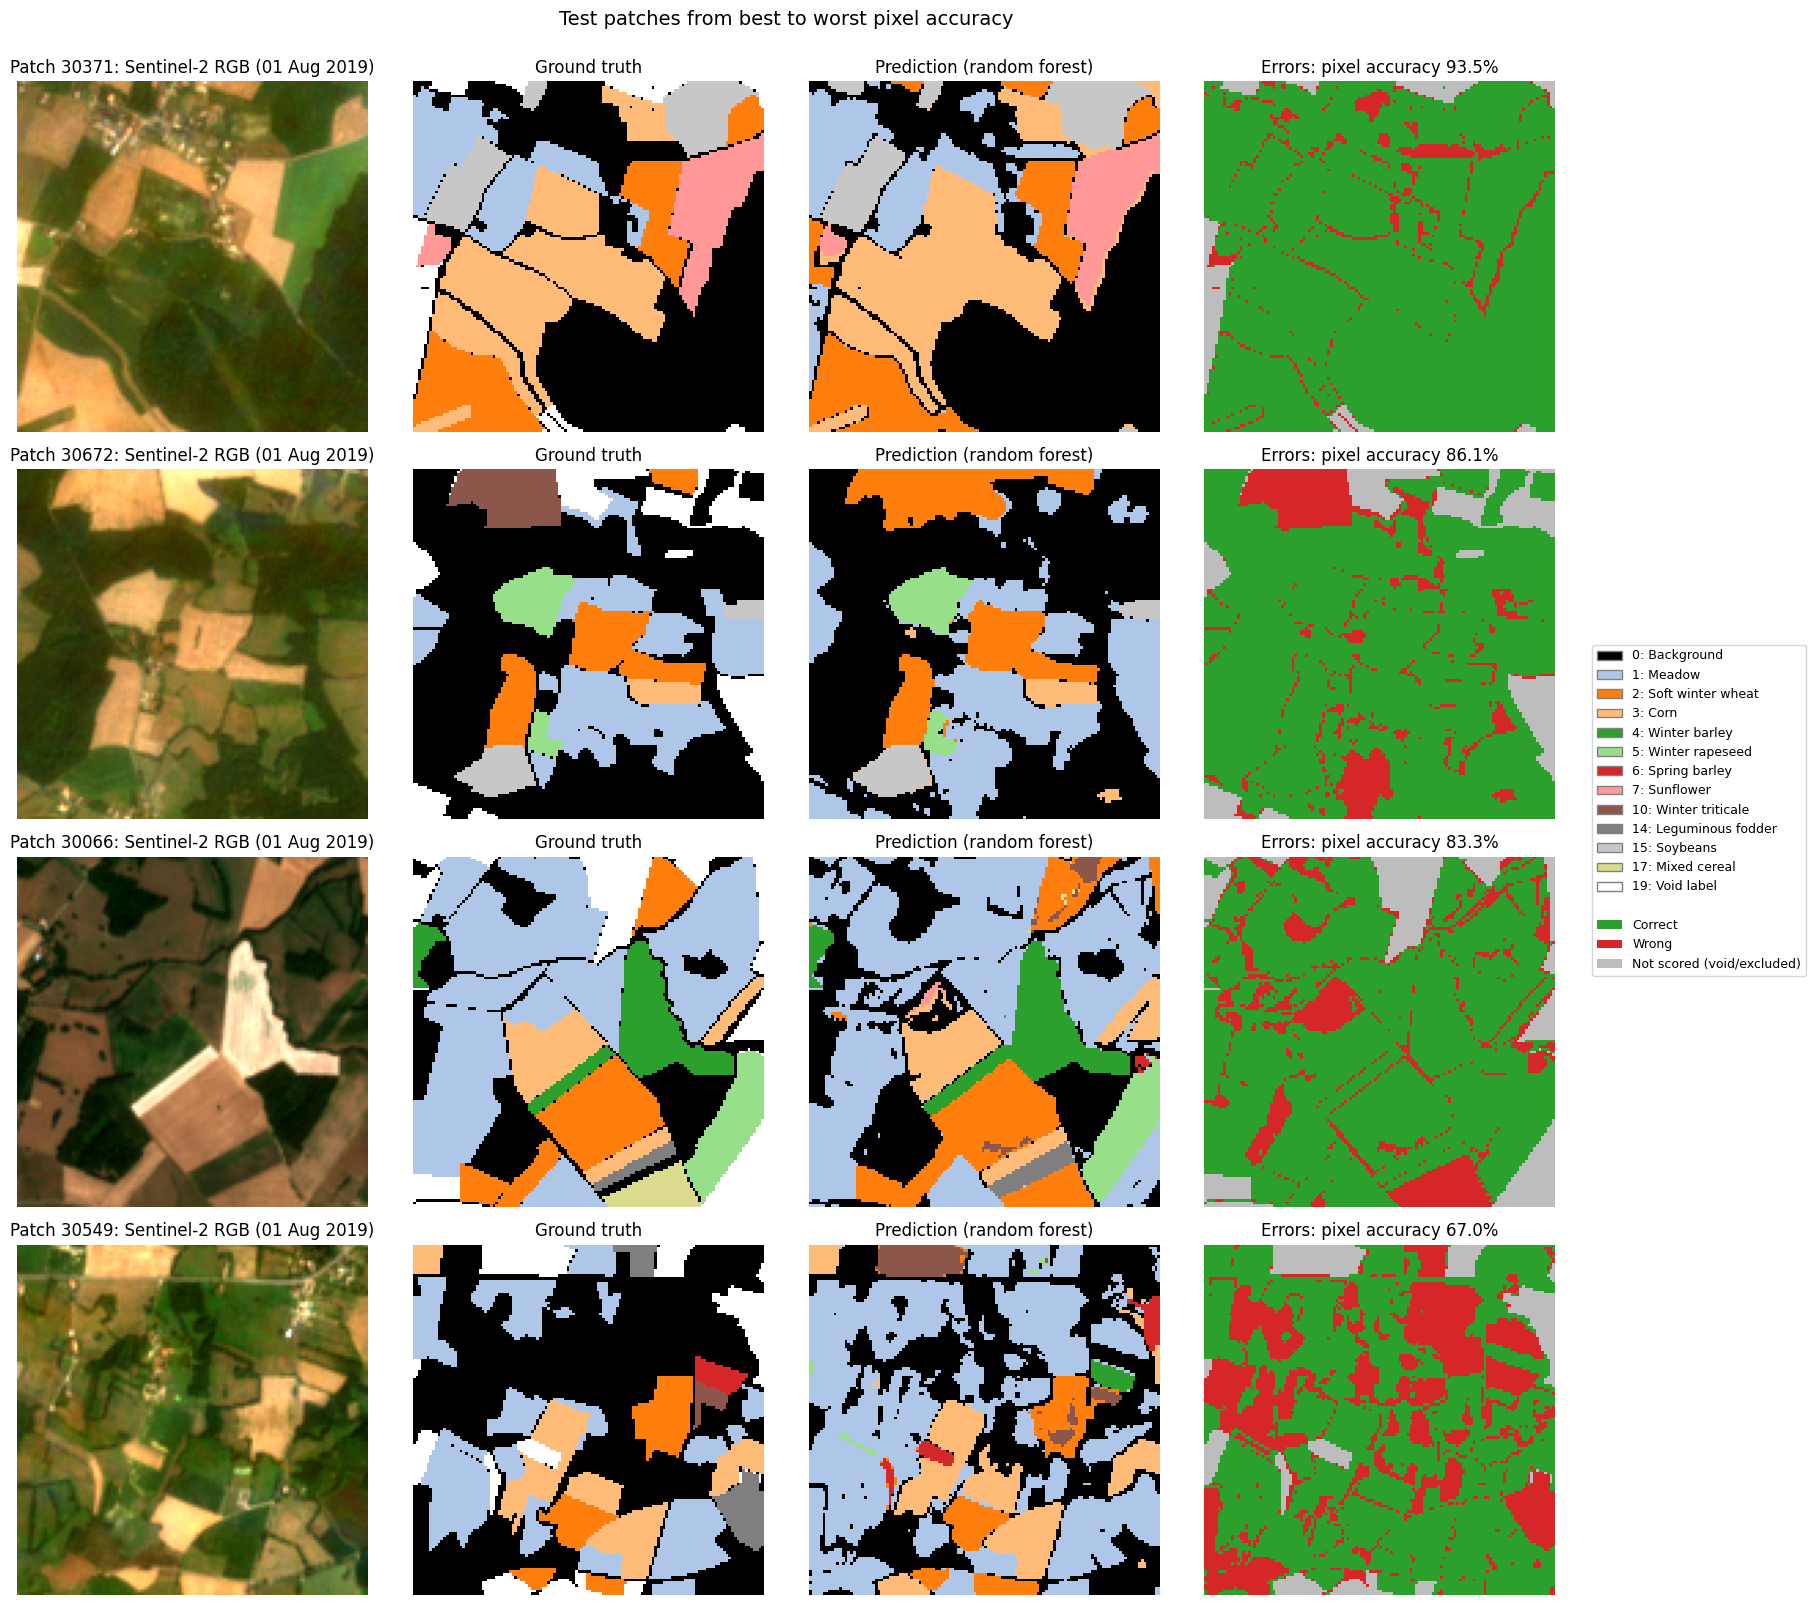

In [24]:
figs["predictions"]

### 8.2 Confusion matrix (test)

Each row shows where the pixels of one true class went.

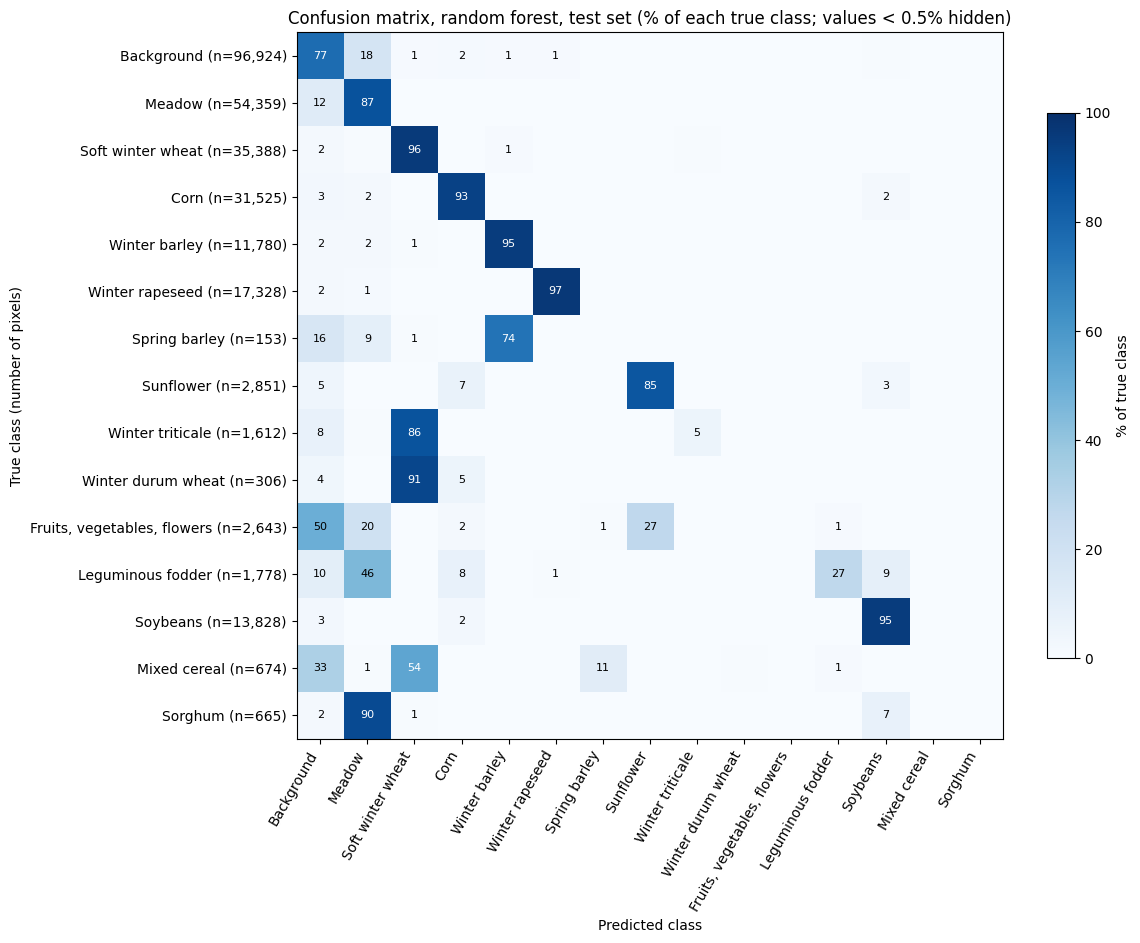

In [25]:
figs["cm_random_forest_test"]

### 8.3 Confusion matrix (validation)

Rare-class scores differ strongly between validation and test (triticale 59% vs 5% correct, spring barley 81% vs 0%). With only a few fields per class, one or two fields decide the score, so rare-class results are unstable.

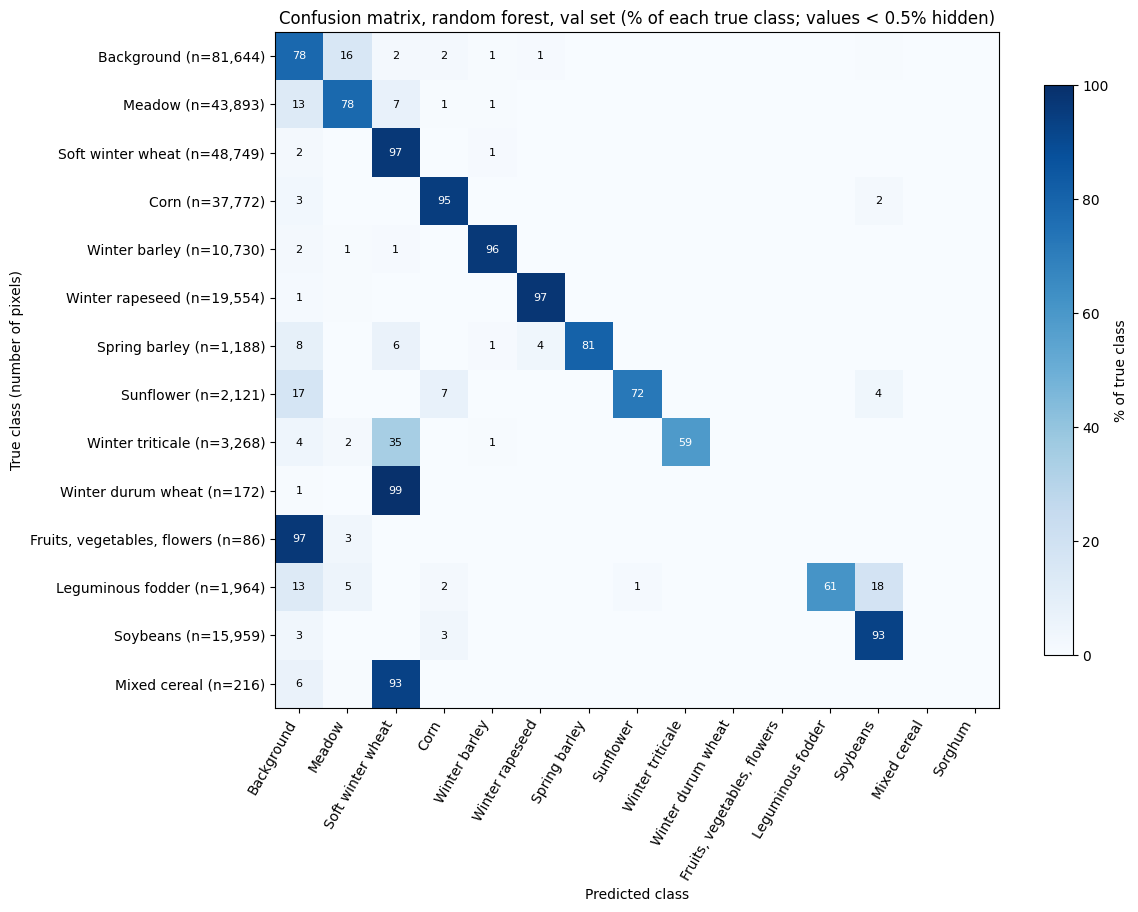

In [26]:
figs["cm_random_forest_val"]

### 8.4 Per-class F1 and IoU

Class size (number of test pixels) is shown next to each name.

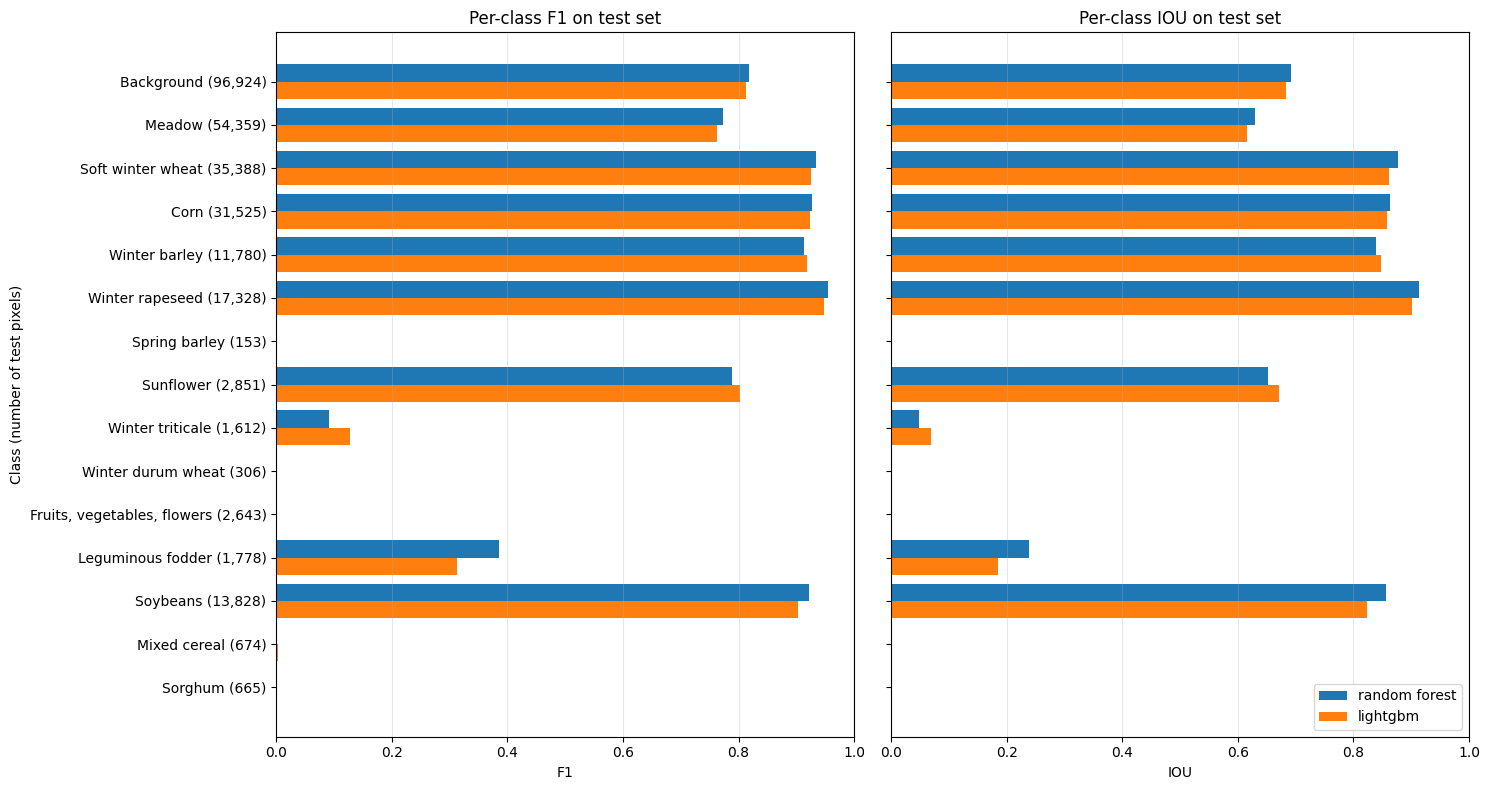

In [27]:
figs["per_class"]

### 8.5 Model comparison

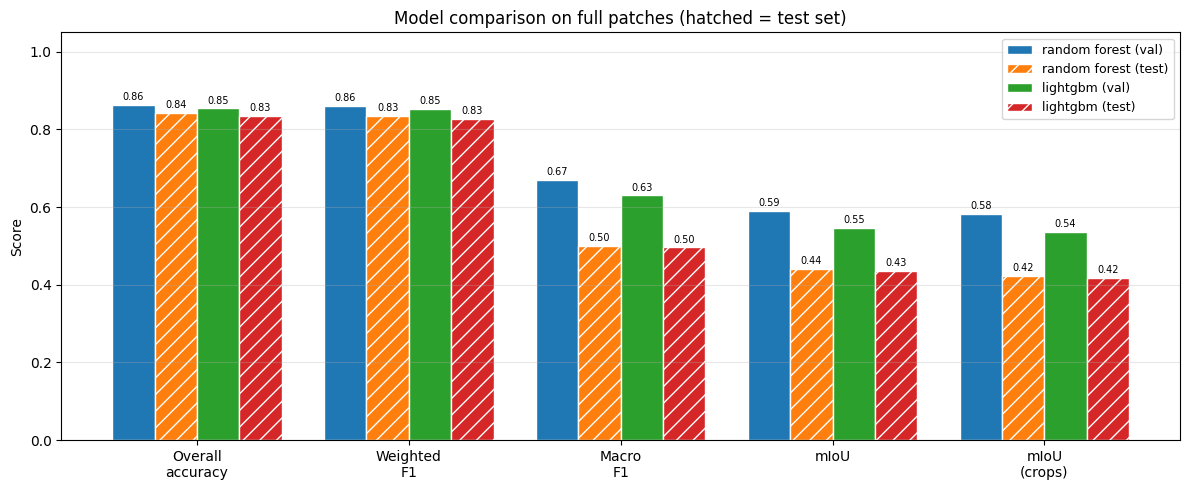

In [28]:
figs["comparison"]

### 8.6 Feature importance

**Red-edge information dominates** (B6, NDRE, B5), consistent with its sensitivity to chlorophyll and canopy structure. The most important dates fall between **mid-May and early July**, when winter cereals ripen while summer crops emerge, with smaller peaks in spring and late August. Autumn and winter dates, when most fields are bare, matter little. Random Forest importance is spread unevenly across correlated features, so these patterns should be read qualitatively.

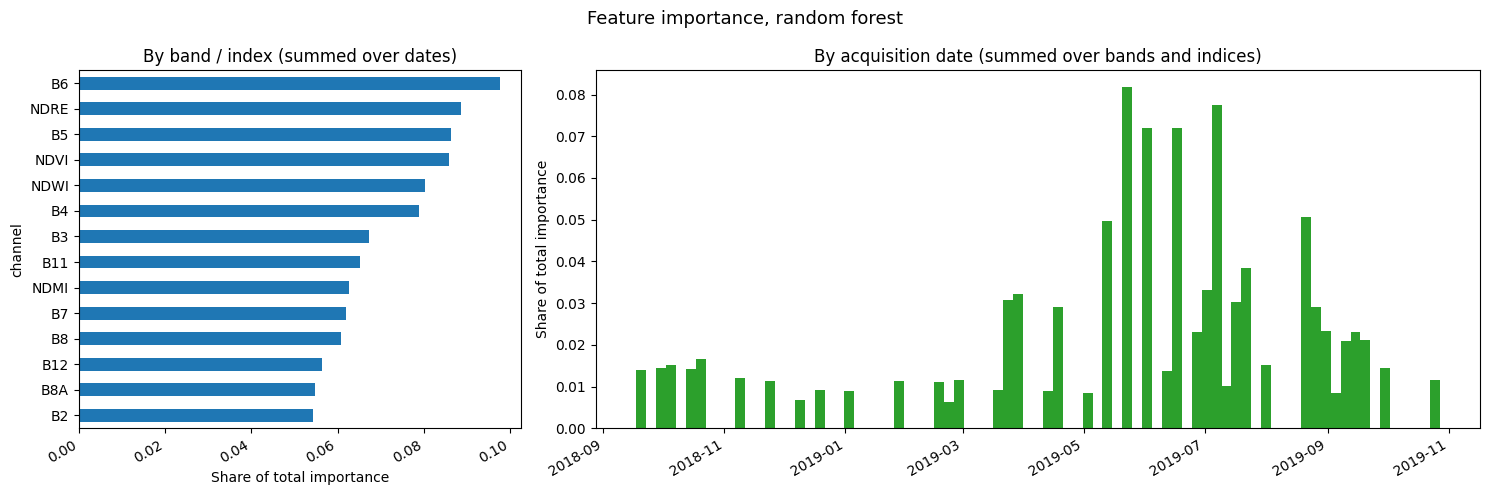

In [29]:
figs["importance_random_forest"]

## 9. Summary

A pixel-wise Random Forest on 41 dates of Sentinel-2 bands and indices maps the major crops of this region accurately (overall accuracy 0.84, F1 above 0.9 for the five main field crops), with a strictly spatial, fold-based evaluation. Its weaknesses are rare classes, spectrally similar cereals and the background/meadow boundary. The full discussion of limitations and next steps is in **`report.md`**.